<a href="https://colab.research.google.com/github/humcoder40/Flyrank_startup_notebook/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/humcoder40/Flyrank_startup_notebook/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

Action: PRIORITY_EDITORIAL_REVIEW

Reason Code: STALE_HIGH_DEMAND

Definition: Content older than 180 days with above-median search volume/impressions, but below-median CTR. These are force-ranked by total trailing impressions.

Action: IGNORE_NO_ACTION

Reason Code: HEALTHY_OR_LOW_DEMAND

Definition: Pages that are either performing well, or are too new/too low-volume to warrant the cost of a manual editorial update.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Intended Use and Limits

Intended Use: This playbook provides directional decision-support. It is a triage tool designed to help the editorial team organize their massive backlog and focus their limited weekly bandwidth on the pages with the highest potential ROI.

Limits & Cost/Value: The model identifies behavioral decay symptoms (e.g., dropping CTR), but it cannot diagnose the root cause. A page might be dropping because Google changed the SERP layout to a "Zero-Click" snippet. The cost of a false positive is high (wasting 4 hours of an editor's time rewriting a page that will never recover its traffic), so the model's output must be treated as a suggestion, not an absolute truth.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Human Review Required: A human SEO editor must review the top 50 flagged URLs by manually checking the actual live search results. They must verify if the page needs a minor update (e.g., fixing a broken link), a total rewrite, or if it should just be left alone because a competitor is unbeatable.

The No-Go List (What NOT to automate):

Do not automate CMS updates or overwrite existing content based on these flags.

Do not hook this queue up to an LLM to auto-generate and publish rewritten pages.

Do not auto-delete or auto-redirect pages just because they receive a low score.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Monitoring: Track the editorial acceptance rate (how many of the Top 50 flagged pages the human editors actually agree to update) and the post-refresh traffic recovery over 90 days.

Retrain Triggers: The model should be retrained quarterly to capture seasonal shifts. It must also be manually triggered for retraining immediately following any major Google Core Algorithm Update, as baseline CTRs and impression patterns will fundamentally shift.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Generating Action Playbook Exports...
Exported ranked queue to: ../outputs/action_playbook_queue.csv
Exported JSON metrics to: ../outputs/playbook_metrics.json


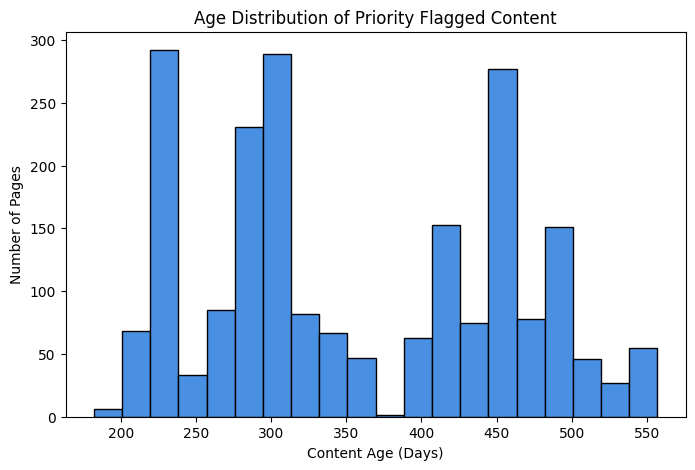

Exported distribution figure to: ../figures/flagged_age_distribution.png


In [2]:
import pandas as pd
import os
import json
import matplotlib.pyplot as plt

print("Generating Action Playbook Exports...")
# 1. Load Data
df = pd.read_csv("https://raw.githubusercontent.com/humcoder40/Flyrank_startup_notebook/main/data/raw/content_refresh_anonymized.csv")

# FIX: Rename columns to match what the export requires
if 'content_id' in df.columns:
    df = df.rename(columns={'content_id': 'content_hash_id'})
if 'ctr' in df.columns:
    df = df.rename(columns={'ctr': 'ctr_90d'})

df = df.fillna(0)

# 2. Build the final output queue
imp_med = df['impressions_90d'].median()
ctr_med = df['ctr_90d'].median()

df['rule_score'] = 0
condition = (df['content_age_days'] > 180) & (df['impressions_90d'] > imp_med) & (df['ctr_90d'] < ctr_med)
df.loc[condition, 'rule_score'] = 100

df['reason_code'] = 'STALE_HIGH_DEMAND'
df['recommended_action'] = 'EDITORIAL_REVIEW'

# Sort by highest impression volume
df_queue = df[df['rule_score'] == 100].sort_values(by='impressions_90d', ascending=False)

# 3. Export CSV (This stays local/out of Git)
os.makedirs('../outputs', exist_ok=True)
csv_path = '../outputs/action_playbook_queue.csv'
df_queue[['content_hash_id', 'impressions_90d', 'ctr_90d', 'reason_code', 'recommended_action']].to_csv(csv_path, index=False)
print(f"Exported ranked queue to: {csv_path}")

# 4. Export JSON metrics (These get committed as receipts)
metrics = {
    "total_pages_evaluated": len(df),
    "pages_flagged_for_review": len(df_queue),
    "median_impressions_flagged": float(df_queue['impressions_90d'].median())
}
json_path = '../outputs/playbook_metrics.json'
with open(json_path, 'w') as f:
    json.dump(metrics, f, indent=4)
print(f"Exported JSON metrics to: {json_path}")

# 5. Export Figure (This gets committed for the paper)
os.makedirs('../figures', exist_ok=True)
plt.figure(figsize=(8,5))
plt.hist(df_queue['content_age_days'], bins=20, color='#4A90E2', edgecolor='black')
plt.title('Age Distribution of Priority Flagged Content')
plt.xlabel('Content Age (Days)')
plt.ylabel('Number of Pages')
fig_path = '../figures/flagged_age_distribution.png'
plt.savefig(fig_path)
plt.show()
print(f"Exported distribution figure to: {fig_path}")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.